## Importing Necessary libraries

In [735]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV, cross_val_score, train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, auc

## Reading and Merging the data files

In [738]:
files = {
    "status": "Telco_customer_churn_status.xlsx",
    "services": "Telco_customer_churn_services.xlsx",
    "location": "Telco_customer_churn_location.xlsx",
    "demographics": "Telco_customer_churn_demographics.xlsx",
    "churn": "Telco_customer_churn.xlsx"
}

dfs = {name: pd.read_excel(file) for name, file in files.items()}

dfs['churn'].rename(columns={"CustomerID": "Customer ID"}, inplace=True)

df = dfs['status']
for key, df_other in dfs.items():
    if key != 'status':
        df = df.merge(df_other, on='Customer ID', how='left', suffixes=(None, f'_{key}'))


In [739]:
df.columns

Index(['Status ID', 'Customer ID', 'Count', 'Quarter', 'Satisfaction Score',
       'Customer Status', 'Churn Label', 'Churn Value', 'Churn Score', 'CLTV',
       'Churn Category', 'Churn Reason', 'Service ID', 'Count_services',
       'Quarter_services', 'Referred a Friend', 'Number of Referrals',
       'Tenure in Months', 'Offer', 'Phone Service',
       'Avg Monthly Long Distance Charges', 'Multiple Lines',
       'Internet Service', 'Internet Type', 'Avg Monthly GB Download',
       'Online Security', 'Online Backup', 'Device Protection Plan',
       'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
       'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds',
       'Total Extra Data Charges', 'Total Long Distance Charges',
       'Total Revenue', 'Location ID', 'Count_location', 'Country', 'State',
       'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude',
       'Count_dem

In [703]:
df.shape

(7043, 91)

## Exploratory Data Analysis

In [705]:
## checking missing values
df.isnull().sum()[df.isnull().sum() > 0]

Churn Category        5174
Churn Reason          5174
Offer                 3877
Internet Type         1526
Churn Reason_churn    5174
dtype: int64

/var/folders/mr/jhkmw9bs4_sgwx59sd88hcfw0000gn/T/ipykernel_38657/4220043689.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=churn_counts.index, y=churn_counts.values, palette=colors)


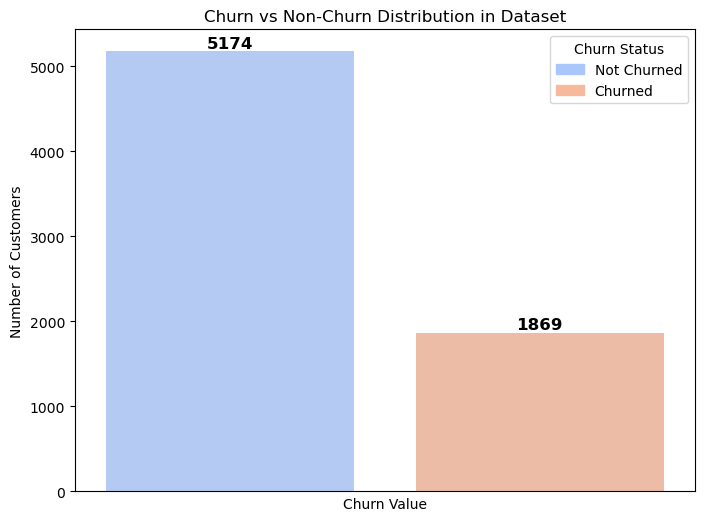

In [719]:
## Analysing Churn VS Non Churn Distribution 
import matplotlib.pyplot as plt
import seaborn as sns

if 'Churn Value' in df.columns:
    churn_counts = df['Churn Value'].value_counts()

    # Define colors from coolwarm palette
    colors = sns.color_palette("coolwarm", n_colors=2)

    # Plot churn distribution with count labels
    plt.figure(figsize=(8, 6))
    ax = sns.barplot(x=churn_counts.index, y=churn_counts.values, palette=colors)

    # Add count labels on bars
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom', fontsize=12, fontweight='bold')

    plt.ylabel("Number of Customers")
    plt.title("Churn vs Non-Churn Distribution in Dataset")

    handles = [plt.Rectangle((0,0),1,1, color=colors[0], label="Not Churned"),
               plt.Rectangle((0,0),1,1, color=colors[1], label="Churned")]
    plt.legend(handles=handles, title="Churn Status", loc="upper right")

    plt.xticks([])

    plt.show()
else:
    print("Churn Value column not found in the dataset.")


## The proportion of churn is an imbalanced data set because both classes are not equally distributed. To handle it, resampling would be needed in future improvements.

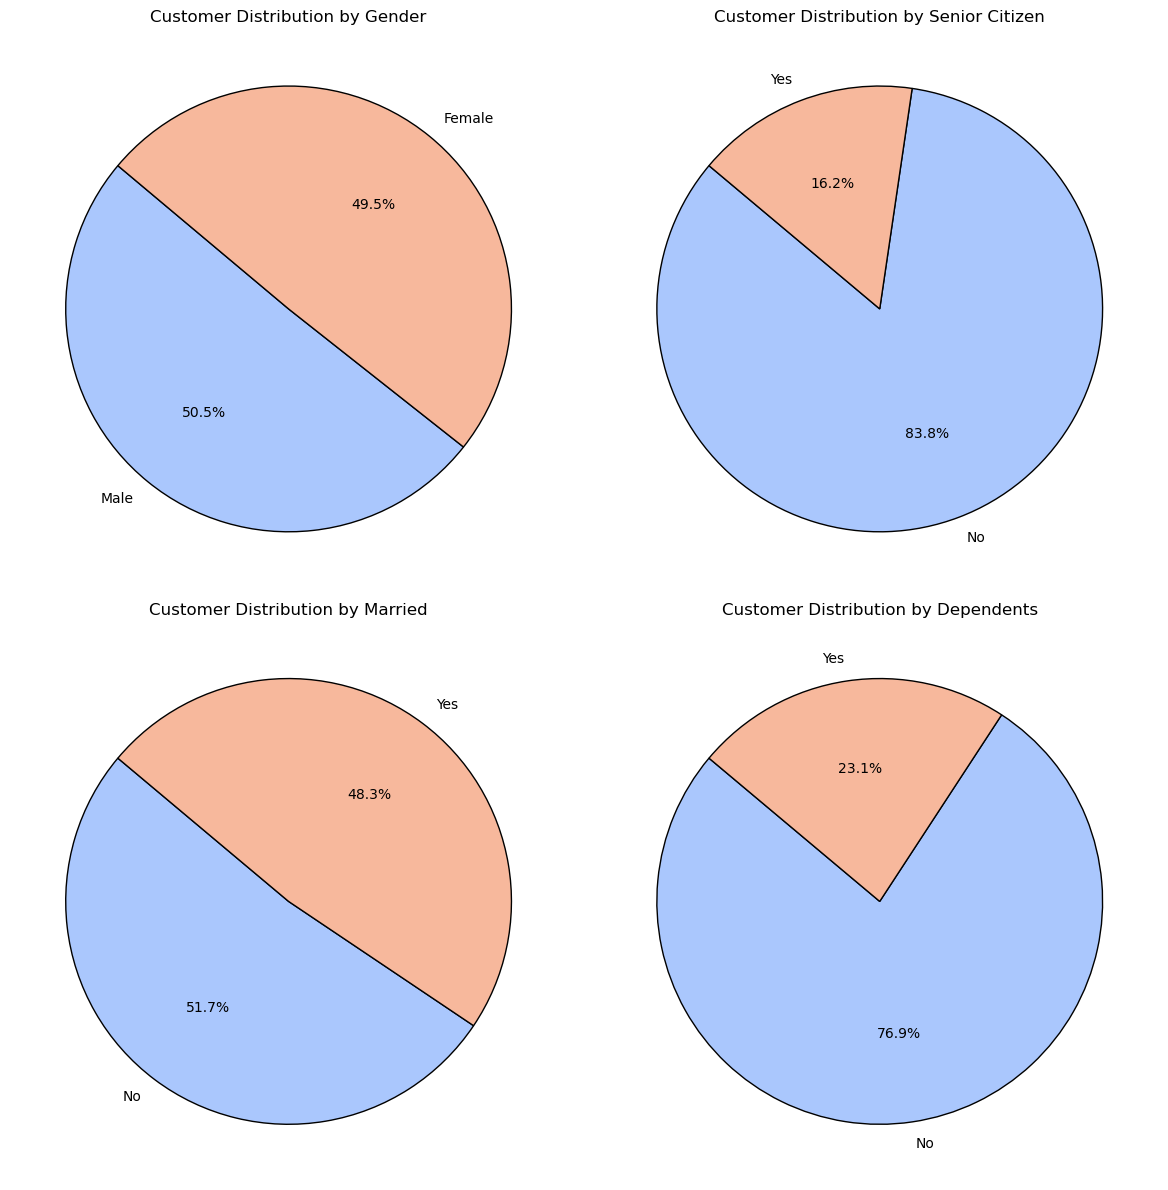

In [722]:
## Customer distribution by demographics
import matplotlib.pyplot as plt
import seaborn as sns

demographic_features = ['Gender', 'Senior Citizen', 'Married', 'Dependents']

fig, axes = plt.subplots(2, 2, figsize=(12, 12))

for ax, feature in zip(axes.flatten(), demographic_features):
    if feature in df.columns:
        customer_counts = df[feature].value_counts() 

        ax.pie(customer_counts, labels=customer_counts.index, autopct='%1.1f%%', 
               colors=sns.color_palette("coolwarm", len(customer_counts)), startangle=140, wedgeprops={'edgecolor': 'black'})
        
        ax.set_title(f"Customer Distribution by {feature}")

plt.tight_layout()
plt.show()

/var/folders/mr/jhkmw9bs4_sgwx59sd88hcfw0000gn/T/ipykernel_38657/2945126633.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_rate.index, y=churn_rate.values, palette="coolwarm", ax=ax)
/var/folders/mr/jhkmw9bs4_sgwx59sd88hcfw0000gn/T/ipykernel_38657/2945126633.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_rate.index, y=churn_rate.values, palette="coolwarm", ax=ax)
/var/folders/mr/jhkmw9bs4_sgwx59sd88hcfw0000gn/T/ipykernel_38657/2945126633.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_rate.index, y=ch

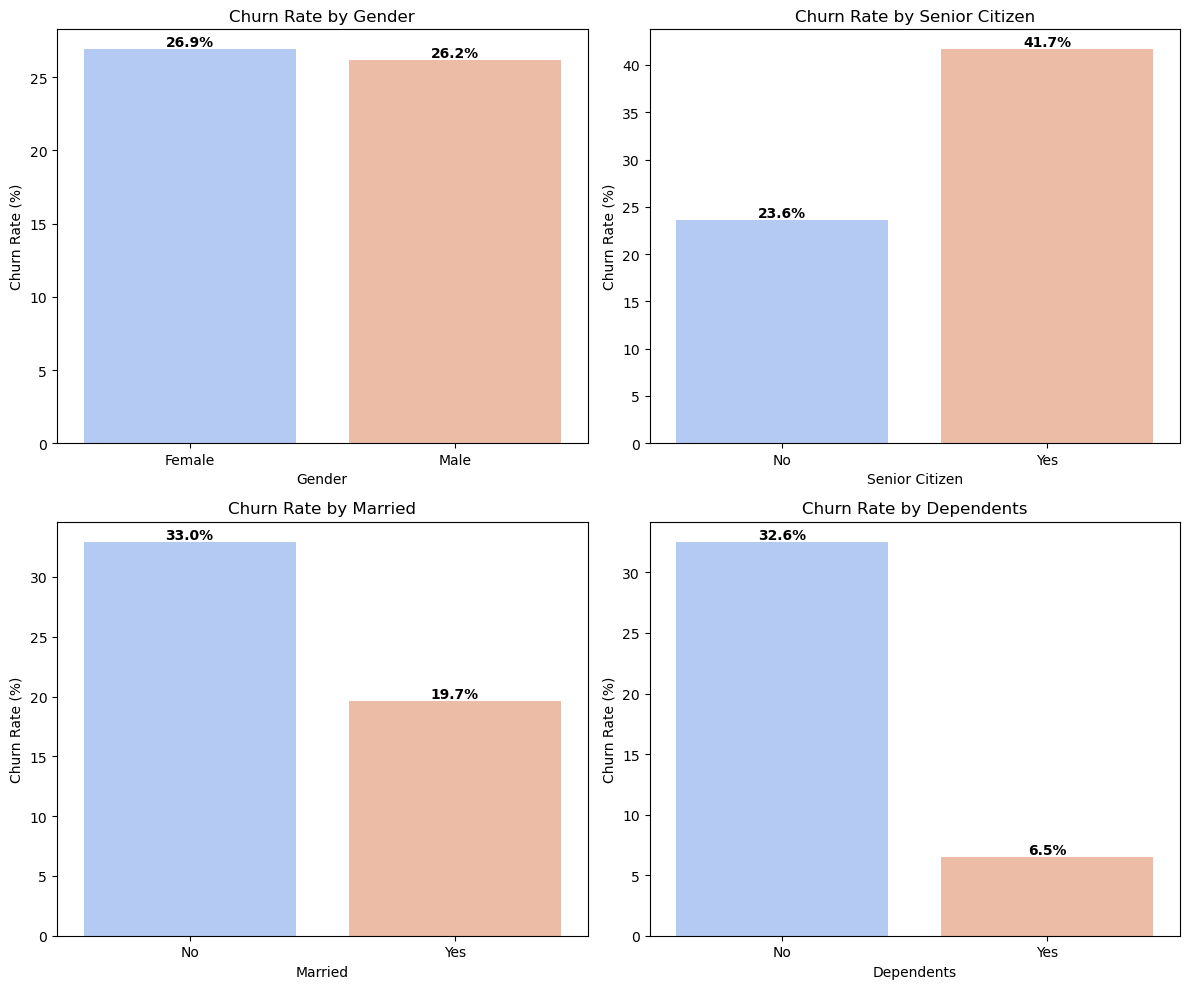

In [724]:
## Analysing Churn rate by demographics
import matplotlib.pyplot as plt
import seaborn as sns

demographic_features = ['Gender', 'Senior Citizen', 'Married', 'Dependents']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, feature in zip(axes.flatten(), demographic_features):
    if feature in df.columns:
        churn_rate = df.groupby(feature)['Churn Value'].mean() * 100  

        sns.barplot(x=churn_rate.index, y=churn_rate.values, palette="coolwarm", ax=ax)
        ax.set_title(f"Churn Rate by {feature}")
        ax.set_ylabel("Churn Rate (%)")
        ax.set_xlabel(feature)

        for p in ax.patches:
            ax.annotate(f'{p.get_height():.1f}%', 
                        (p.get_x() + p.get_width() / 2., p.get_height()), 
                        ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

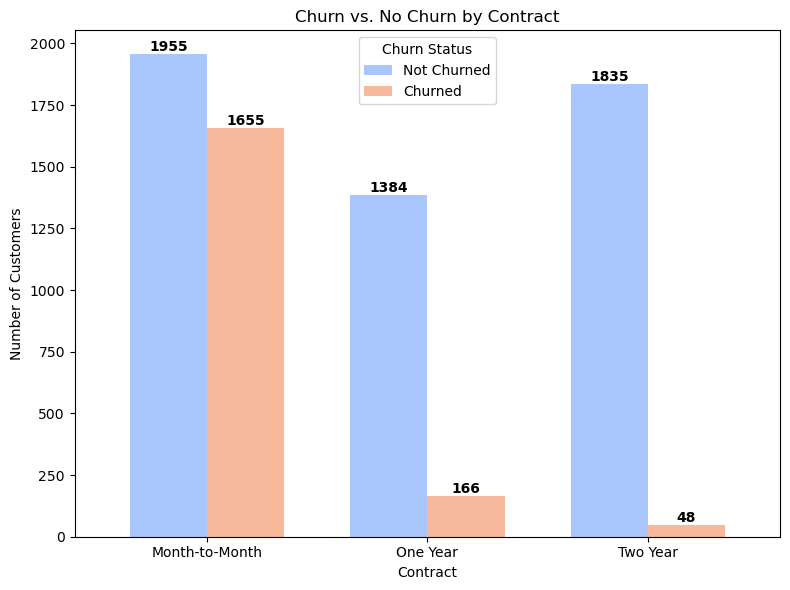

In [726]:
## Analysing the impact of contract type on Churn
import matplotlib.pyplot as plt
import seaborn as sns

customer_account_cat = ["Contract"]

fig, ax = plt.subplots(figsize=(8, 6))

for feature in customer_account_cat:
    if feature in df.columns:
        churn_counts = df.groupby(feature)['Churn Value'].value_counts().unstack()

        churn_counts.plot(kind='bar', color=sns.color_palette("coolwarm", 2), ax=ax, width=0.7)

        ax.set_title(f"Churn vs. No Churn by {feature}")
        ax.set_ylabel("Number of Customers")
        ax.set_xlabel(feature)
        ax.legend(["Not Churned", "Churned"], title="Churn Status")

        # Add count labels on bars
        for p in ax.patches:
            ax.annotate(f'{int(p.get_height())}', 
                        (p.get_x() + p.get_width() / 2., p.get_height()), 
                        ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## There is a trend that customers who churned were more likely to be on a Month-to-Month contract

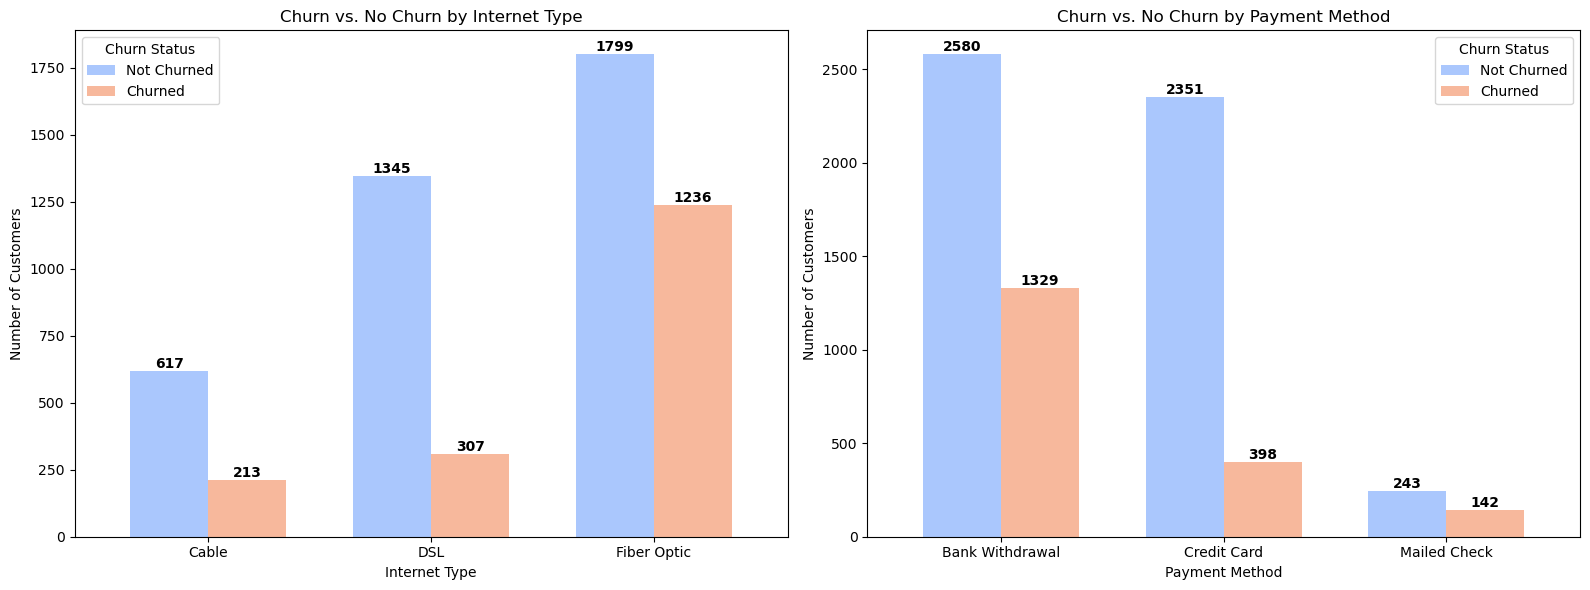

In [858]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define features to analyze
features = ["Internet Type", "Payment Method"]

# Create subplots for side-by-side visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Loop through features and create bar plots
for i, feature in enumerate(features):
    if feature in df.columns:
        churn_counts = df.groupby(feature)['Churn Value'].value_counts().unstack()
        churn_counts.plot(kind='bar', color=sns.color_palette("coolwarm", 2), ax=axes[i], width=0.7)

        axes[i].set_title(f"Churn vs. No Churn by {feature}")
        axes[i].set_ylabel("Number of Customers")
        axes[i].set_xlabel(feature)
        axes[i].legend(["Not Churned", "Churned"], title="Churn Status")

        # Add count labels on bars
        for p in axes[i].patches:
            if p.get_height() > 0:  # Avoid printing labels for empty bars
                axes[i].annotate(f'{int(p.get_height())}', 
                                 (p.get_x() + p.get_width() / 2., p.get_height()), 
                                 ha='center', va='bottom', fontsize=10, fontweight='bold')
        axes[i].tick_params(axis='x', rotation=0)
# Adjust layout
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


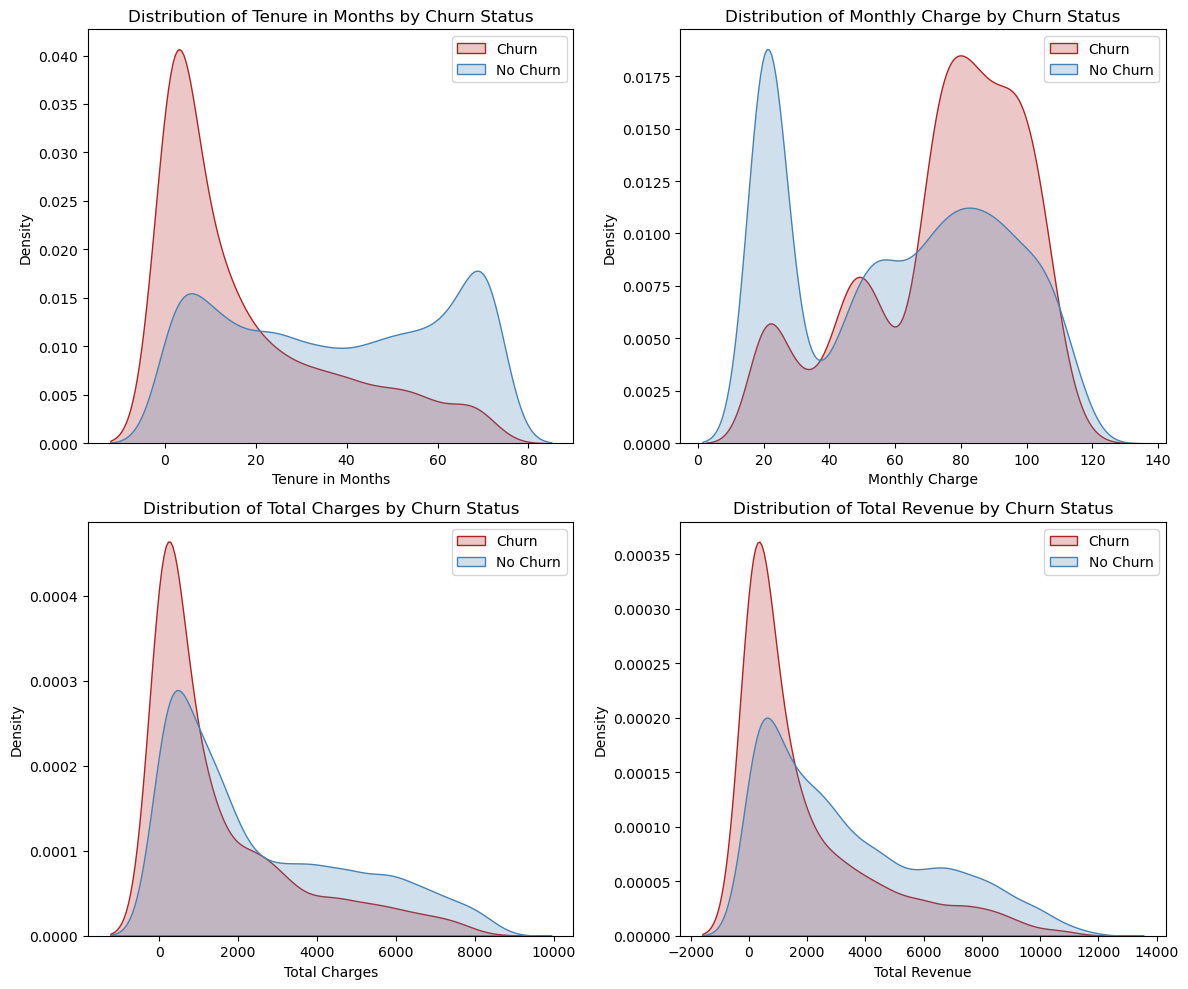

In [729]:
## Analysing the distribution of numerical features for churn vs. non-churn customers
import matplotlib.pyplot as plt
import seaborn as sns
import math

customer_account_num = ["Tenure in Months", "Monthly Charge", "Total Charges","Total Revenue"]

def histogram_plots(df, numerical_values, target):
    number_of_columns = 2  
    number_of_rows = math.ceil(len(numerical_values) / number_of_columns) 
    
    fig, axes = plt.subplots(number_of_rows, number_of_columns, figsize=(12, 5 * number_of_rows))
    axes = axes.flatten()

    for index, column in enumerate(numerical_values):
        if column in df.columns:
            sns.kdeplot(df[df[target] == 1][column], fill=True, label="Churn", ax=axes[index], color="firebrick")
            sns.kdeplot(df[df[target] == 0][column], fill=True, label="No Churn", ax=axes[index], color="steelblue")
            axes[index].set_title(f"Distribution of {column} by Churn Status")
            axes[index].legend(loc='upper right')

    plt.tight_layout()
    plt.show()

histogram_plots(df, customer_account_num, "Churn Value")

In [742]:
## Analysing regional churn data by zip codes
import pandas as pd

zip_churn_counts = df.groupby("Zip Code").agg(
    Total_Customers=("Churn Value", "count"),
    Churned_Customers=("Churn Value", "sum")  
).reset_index()

zip_churn_counts = zip_churn_counts.sort_values(by="Churned_Customers", ascending=False)

print(zip_churn_counts.head(5))  # Show top 5 zip codes with highest churn

     Zip Code  Total_Customers  Churned_Customers
369     92122               36                 33
364     92117               34                 30
372     92126               32                 28
324     92028               43                 26
357     92109               27                 24


## There are some Zip Codes that clearly present higher churn rates. Possibly due to high competition from competitor

<Figure size 1200x600 with 0 Axes>

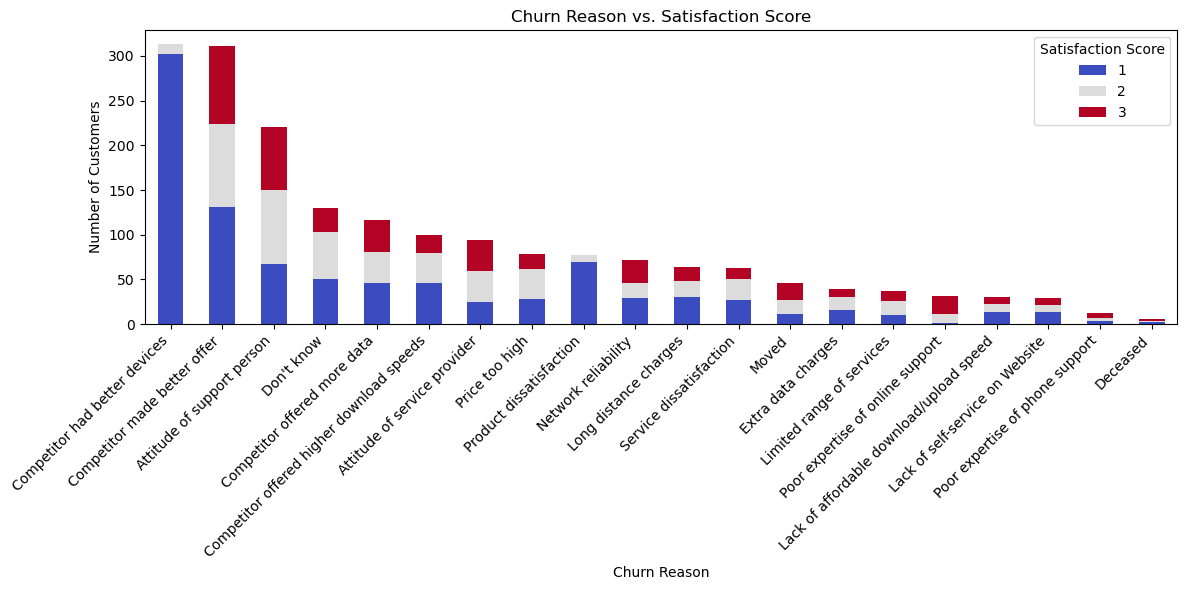

In [745]:
## Analysing the relation between churn and satisfaction score
import pandas as pd
import matplotlib.pyplot as plt

churn_reason_counts = df[df["Churn Value"] == 1]["Churn Reason"].value_counts()

churn_reason_satisfaction = df[df["Churn Value"] == 1].groupby(["Churn Reason", "Satisfaction Score"]).size().unstack()
churn_reason_satisfaction = churn_reason_satisfaction.loc[churn_reason_counts.index]  # Reorder by total churn count

plt.figure(figsize=(12, 6))
churn_reason_satisfaction.plot(kind="bar", stacked=True, colormap="coolwarm", figsize=(12, 6))

plt.title("Churn Reason vs. Satisfaction Score")
plt.xlabel("Churn Reason")
plt.ylabel("Number of Customers")
plt.legend(title="Satisfaction Score", loc="upper right")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

## Majority of the customers that left, had low Satisfaction Scores and Churn Reasons like Competitor had better devices, better offers and due to Product dissatisfaction

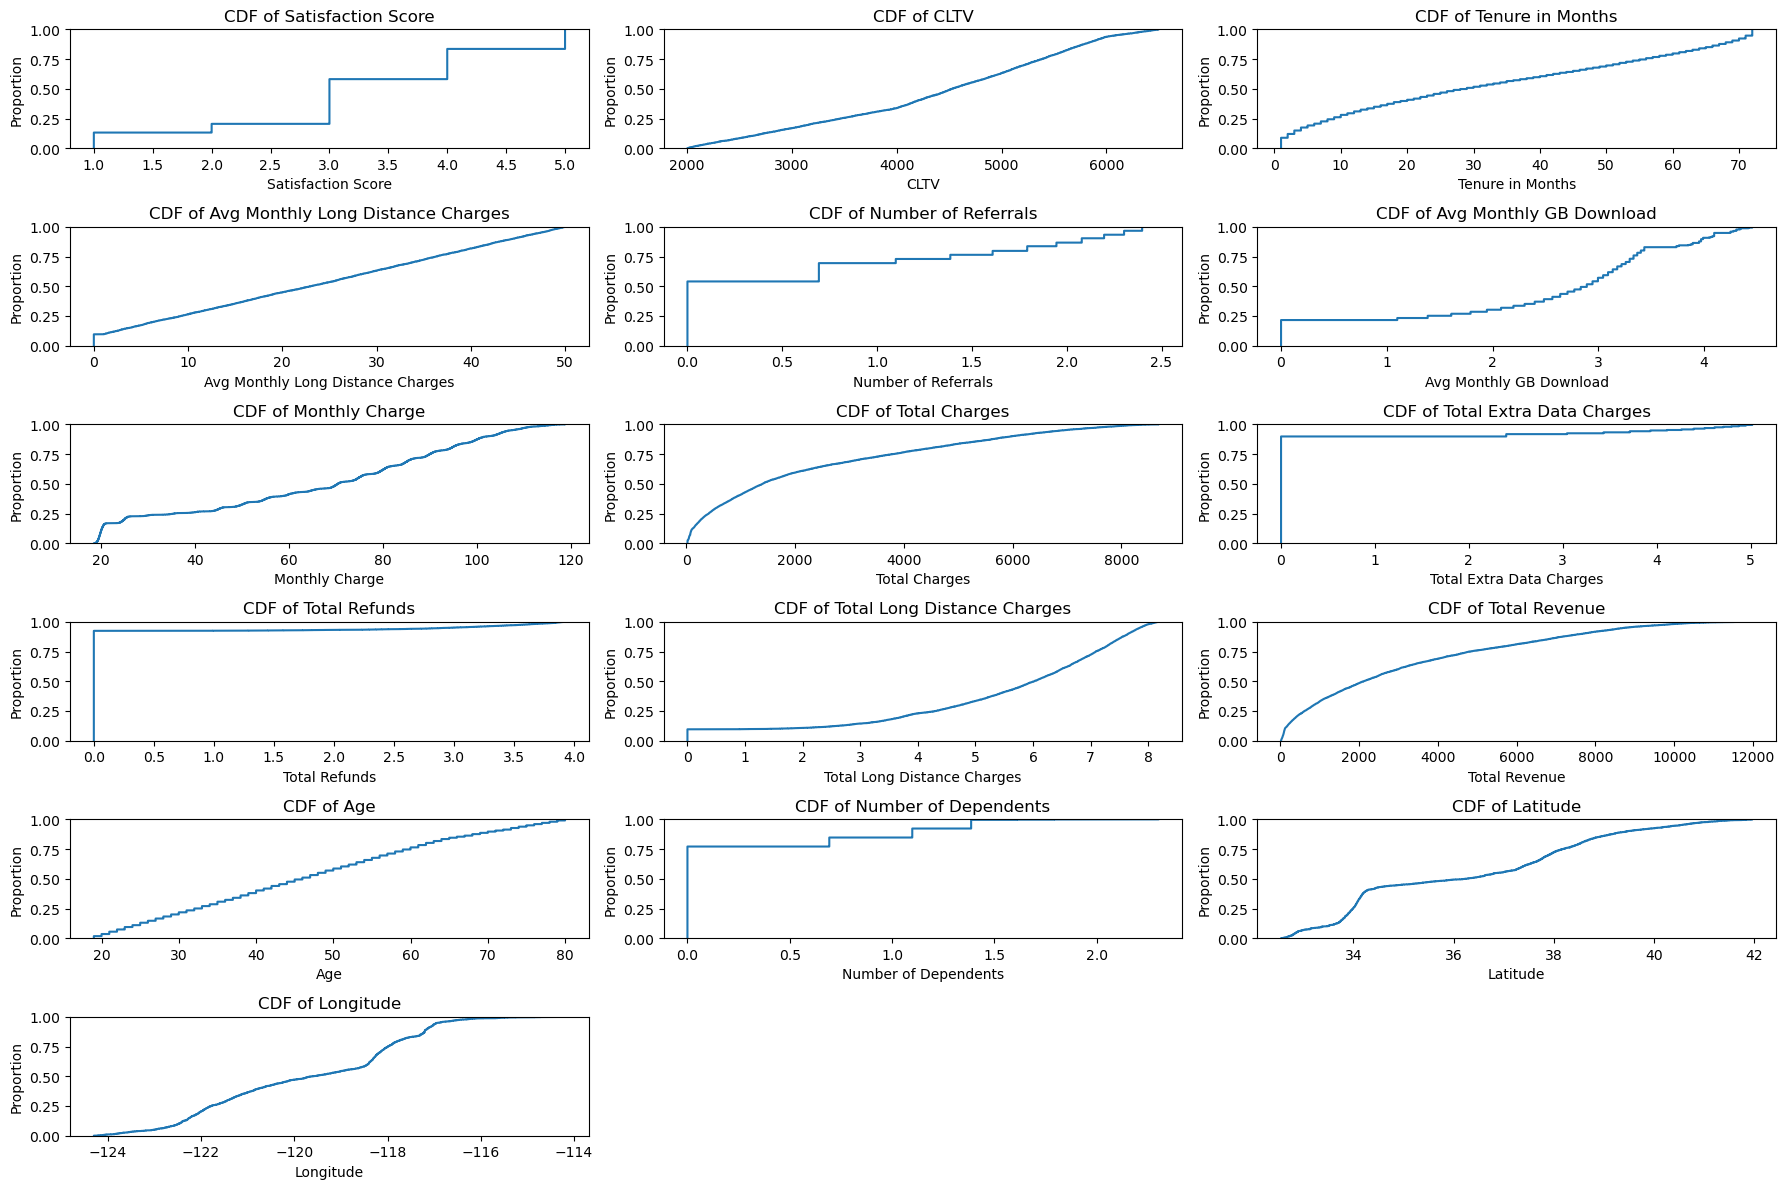

In [748]:
# Plotting Cumulative Distribution Functions (CDF) for num_vars and skewed_features
num_features = len(numerical_columns)  

fig, axes = plt.subplots(nrows=(num_features // 3) + 1, ncols=3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(numerical_columns):
    sns.ecdfplot(X_train[col], ax=axes[i])
    axes[i].set_title(f"CDF of {col}")

for i in range(num_features, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()


In [707]:
# Checking for skewness in the data
import pandas as pd

numerical_columns = [
    'Satisfaction Score', 'CLTV', 'Tenure in Months', 'Avg Monthly Long Distance Charges', 'Number of Referrals',
    'Avg Monthly GB Download', 'Monthly Charge', 'Total Charges', 'Total Extra Data Charges', 'Total Refunds',
    'Total Long Distance Charges', 'Total Revenue', 'Age', 'Number of Dependents', 'Latitude', 'Longitude'
]

skewness = df[numerical_columns].skew()
highly_skewed_features = skewness[abs(skewness) > 1]

print("Highly Skewed Features:\n", highly_skewed_features)


Highly Skewed Features:
 Number of Referrals            1.446060
Avg Monthly GB Download        1.216584
Total Extra Data Charges       4.091209
Total Refunds                  4.328517
Total Long Distance Charges    1.238282
Number of Dependents           2.109932
dtype: float64


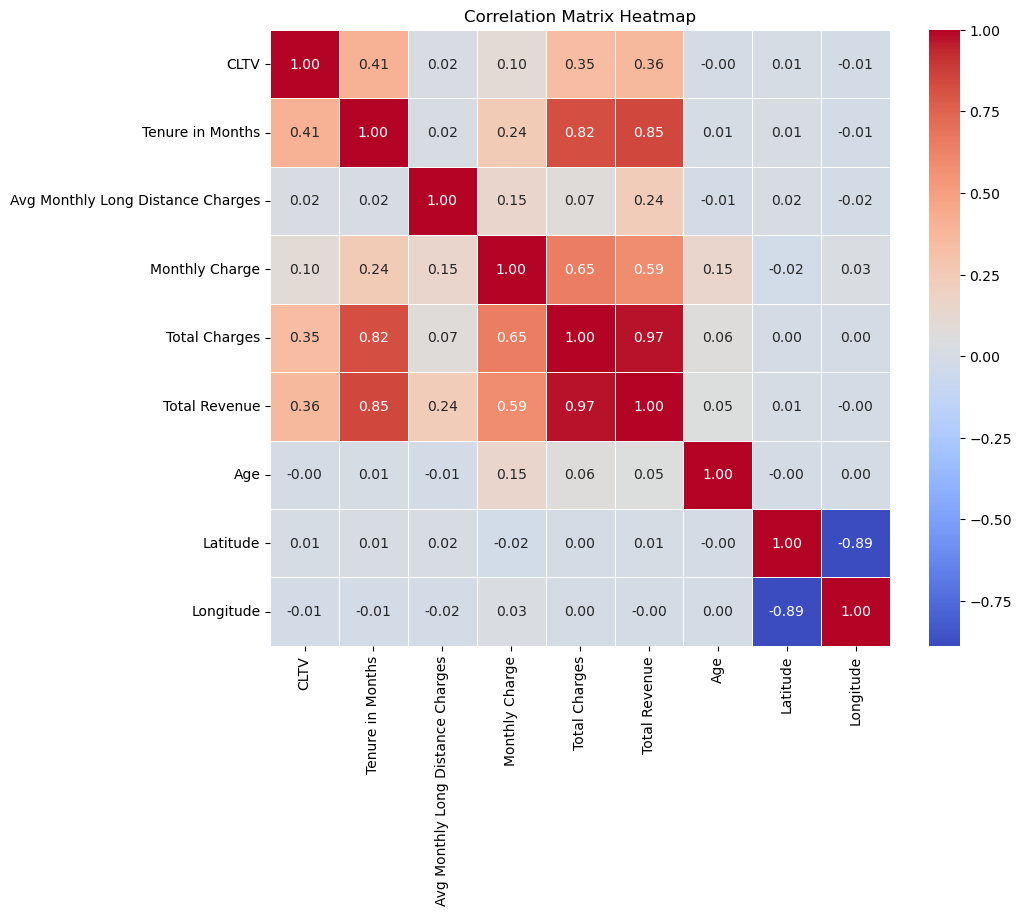

In [711]:
# Correlation matrix for numerical features
correlation_matrix = X_train[num_vars].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)

plt.title("Correlation Matrix Heatmap")
plt.show()

## Discarding Unnecessary Features

## **1️⃣ Identifiers & Non-Predictive Fields**
- **`Customer ID`, `Service ID`, `Location ID`** → Unique identifiers, do not contribute to churn prediction.
- **`Count`, `Count_services`, `Count_location`, `Count_demographics`, `Count_churn`** → Reporting fields, not useful for modeling.

---

## **2️⃣ Duplicate or Highly Correlated Features**
- **`Tenure Months`** → Duplicate of `Tenure in Months`.
- **`Country`, `State`, `City`, `Zip Code`** → Latitude & Longitude already capture location.
- **`Phone Service_churn`, `Contract_churn`, `Payment Method_churn`** → Redundant versions of selected features.

---

## **3️⃣ Churn-Related Fields (Data Leakage Risk)**
- **`Customer Status`, `Churn Label`, `Churn Reason`, `Churn Score`** → These directly indicate churn, causing data leakage.
- **`Churn Value_churn`, `Churn Reason_churn`** → Post-churn information, not useful for prediction.

---

## **4️⃣ Non-Informative Features**
- **`Quarter`, `Quarter_services`** → Time-based, not directly linked to churn.
- **`Under 30`** → Already covered by `Age`.
- **`Partner`** → Too similar to `Married`.

In [750]:
# Keeping only the selected columns
selected_columns = [
    # Numerical Features
    'Satisfaction Score', 'CLTV', 'Tenure in Months', 'Avg Monthly Long Distance Charges','Number of Referrals',
    'Avg Monthly GB Download', 'Monthly Charge', 'Total Charges', 'Total Extra Data Charges','Total Refunds',
    'Total Long Distance Charges', 'Total Revenue', 'Age', 'Number of Dependents', 'Latitude', 'Longitude',
    # Categorical Features
    'Gender', 'Senior Citizen', 'Married', 'Dependents', 'Offer', 'Phone Service', 'Multiple Lines',
    'Internet Type', 'Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support','Tech Support',
    'Streaming TV', 'Streaming Movies', 'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing', 'Payment Method',
    # Target Variable
    'Churn Value'
]
df = df[selected_columns]
df.head()


,Satisfaction Score,CLTV,Tenure in Months,Avg Monthly Long Distance Charges,Number of Referrals,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Extra Data Charges,Total Refunds,...,Premium Tech Support,Tech Support,Streaming TV,Streaming Movies,Streaming Music,Unlimited Data,Contract,Paperless Billing,Payment Method,Churn Value
0,3,5433,1,0.00,0,8,39.65,39.65,20,0.00,...,No,No,No,Yes,No,No,Month-to-Month,Yes,Bank Withdrawal,1
1,3,5302,8,48.85,1,17,80.65,633.30,0,0.00,...,No,No,No,No,No,Yes,Month-to-Month,Yes,Credit Card,1
2,2,3179,18,11.33,0,52,95.45,1752.55,0,45.61,...,No,No,Yes,Yes,Yes,Yes,Month-to-Month,Yes,Bank Withdrawal,1
3,2,5337,25,19.76,1,12,98.50,2514.50,0,13.43,...,No,No,Yes,Yes,No,Yes,Month-to-Month,Yes,Bank Withdrawal,1
4,2,2793,37,6.33,1,14,76.50,2868.15,0,0.00,...,No,No,No,No,No,Yes,Month-to-Month,Yes,Bank Withdrawal,1


In [752]:
df.shape

(7043, 37)

## Train-Test Data Split

In [754]:
X = df.drop(columns=['Churn Value'])
y = df['Churn Value']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")

Train size: (5634, 36), Test size: (1409, 36)


## Preprocessing - One-hot encoding, Feature scaling, Handling outliers and missing values

In [686]:
# Create missing flags for 'Offer' and 'Internet Type' 
X_train['Offer_Missing'] = X_train['Offer'].isnull().astype(int)
X_test['Offer_Missing'] = X_test['Offer'].isnull().astype(int)

X_train['Internet_Type_Missing'] = X_train['Internet Type'].isnull().astype(int)
X_test['Internet_Type_Missing'] = X_test['Internet Type'].isnull().astype(int)

# Defining Feature Groups
skewed_features = ["Number of Referrals", "Avg Monthly GB Download", "Total Extra Data Charges", "Total Refunds", "Total Long Distance Charges", "Number of Dependents"]
num_vars = ["CLTV", "Tenure in Months", "Avg Monthly Long Distance Charges", "Monthly Charge", "Total Charges", "Total Revenue", "Age", "Latitude", "Longitude"]
ordinal_features = ["Satisfaction Score"]
nominal_features = [col for col in X_train.columns if col not in num_vars + skewed_features + ordinal_features]

#Transforming Highly Skewed Features using Log Transformation
for col in skewed_features:
    X_train[col] = np.log1p(X_train[col])
    X_test[col] = np.log1p(X_test[col])

# Preprocessing Pipelines
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])
nominal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False))
])
ordinal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("ordinal", OrdinalEncoder())
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipeline, num_vars),
        ("nominal", nominal_pipeline, nominal_features),
        ("ordinal", ordinal_pipeline, ordinal_features)
    ],
    remainder="drop"
)

# Preprocessing the train and test data
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()
feature_names = [name.split("__")[-1] for name in feature_names] 

X_train_transformed = pd.DataFrame(X_train_transformed, index=X_train.index, columns=feature_names)
X_test_transformed = pd.DataFrame(X_test_transformed, index=X_test.index, columns=feature_names)


In [688]:
X_train_transformed

,CLTV,Tenure in Months,Avg Monthly Long Distance Charges,Monthly Charge,Total Charges,Total Revenue,Age,Latitude,Longitude,Gender_Male,...,Streaming Music_Yes,Unlimited Data_Yes,Contract_One Year,Contract_Two Year,Paperless Billing_Yes,Payment Method_Credit Card,Payment Method_Mailed Check,Offer_Missing_1,Internet_Type_Missing_1,Satisfaction Score
4626,-0.529959,-0.670324,-1.114694,-0.318343,-0.622239,-0.724186,-0.211366,2.251686,-1.000550,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,4.0
4192,1.269461,-0.832749,-0.390338,1.341246,-0.446078,-0.546188,0.919362,0.613164,-1.229704,0.0,...,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0
5457,0.745260,-1.279415,1.699724,-0.527452,-0.985892,-1.027060,-0.865998,0.701680,-0.195104,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,2.0
4717,0.728459,1.035130,0.260091,0.116469,0.740620,0.867025,-1.342094,-0.923705,0.728746,0.0,...,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0
4673,-0.115807,-1.198203,-0.246375,0.501494,-0.901267,-0.957191,0.145706,-0.907290,0.695222,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6507,-0.130928,-0.548506,0.575254,-1.485035,-0.836840,-0.716564,0.086194,1.436743,-1.669065,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,2.0
2312,-0.036001,-0.954567,-1.490166,-0.535750,-0.812856,-0.903790,0.264730,0.998306,-1.224891,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
1888,0.073208,-1.279415,-0.709392,0.999371,-0.965649,-1.023978,-0.270878,-0.630540,1.148854,1.0,...,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3870,0.680575,-0.913961,0.745156,-1.330693,-0.908924,-0.863258,0.859850,-0.868604,1.105118,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,2.0


/var/folders/mr/jhkmw9bs4_sgwx59sd88hcfw0000gn/T/ipykernel_38657/1432012590.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlations.values, y=correlations.index, palette="coolwarm")


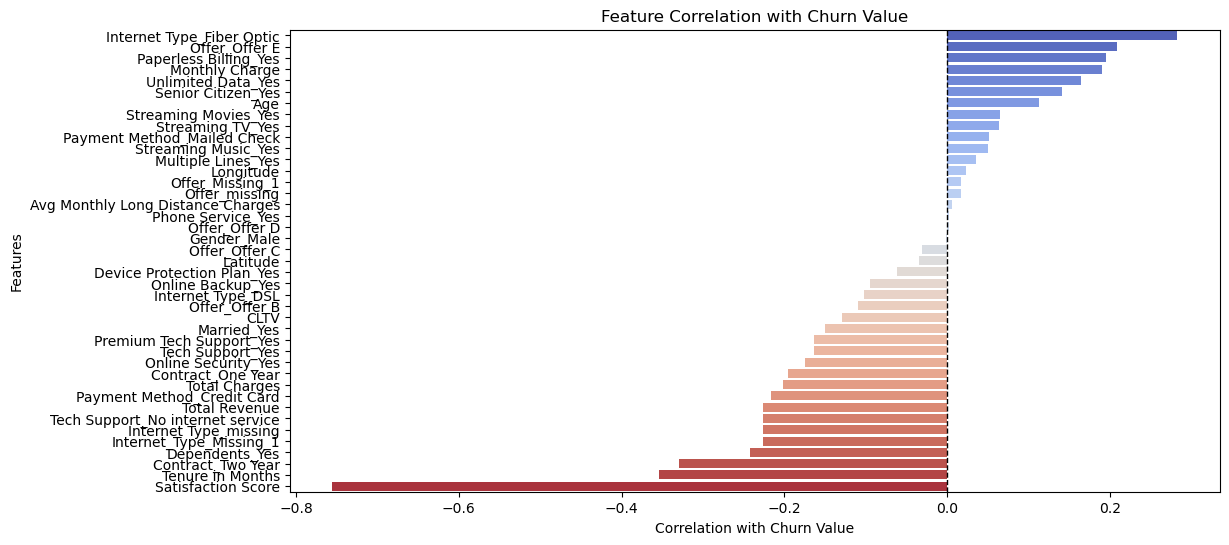

In [690]:
## Analysing the feature correlation
correlations = X_train_transformed.corrwith(y_train).sort_values(ascending=False)

corr_df = pd.DataFrame({"Feature": correlations.index, "Correlation": correlations.values})
corr_df = corr_df[corr_df["Feature"] != "Churn Value"]

plt.figure(figsize=(12, 6))
sns.barplot(x=correlations.values, y=correlations.index, palette="coolwarm")
plt.xlabel("Correlation with Churn Value")
plt.ylabel("Features")
plt.title("Feature Correlation with Churn Value")
plt.axvline(x=0, color="black", linestyle="--", linewidth=1)  # Reference line at 0
plt.show()


## Feature selection (Optional- tried out)

In [694]:
from sklearn.linear_model import LassoCV
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# Feature Selection Using Lasso
lasso = LassoCV(cv=5, random_state=42)
lasso.fit(X_train_transformed, y_train)
lasso_selected = X_train_transformed.columns[lasso.coef_ != 0]
print("Selected Features by Lasso:", lasso_selected)

# Reduce feature set
#X_train = X_train[lasso_selected]
#X_test = X_test[lasso_selected]


Selected Features by Lasso: Index(['CLTV', 'Avg Monthly Long Distance Charges', 'Monthly Charge',
       'Total Charges', 'Age', 'Latitude', 'Longitude', 'Gender_Male',
       'Senior Citizen_Yes', 'Married_Yes', 'Dependents_Yes', 'Offer_Offer B',
       'Offer_Offer C', 'Offer_Offer D', 'Offer_Offer E', 'Offer_missing',
       'Phone Service_Yes', 'Multiple Lines_Yes', 'Internet Type_DSL',
       'Online Security_Yes', 'Online Backup_Yes', 'Premium Tech Support_Yes',
       'Tech Support_Yes', 'Streaming TV_Yes', 'Streaming Movies_Yes',
       'Streaming Music_Yes', 'Unlimited Data_Yes', 'Contract_One Year',
       'Contract_Two Year', 'Paperless Billing_Yes',
       'Payment Method_Credit Card', 'Payment Method_Mailed Check',
       'Offer_Missing_1', 'Satisfaction Score'],
      dtype='object')


<b>As our Tree-Based Models Handle Feature Selection Internally, we decided to skip this step

## GridSearchCV for Hyperparameter tuning

In [826]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    #"XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    "SVM": SVC(kernel='linear', probability=True),
    "LightGBM": LGBMClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

param_grids = {
    "Random Forest": {
        'n_estimators': [100, 200],
        'max_depth': [5, 10, None],
        'min_samples_split': [2, 5]
    },
   # "XGBoost": {
   #     'n_estimators': [100, 200],
   #     'learning_rate': [0.01, 0.1],
   #     'max_depth': [3, 5]
   # },
    "Gradient Boosting": {
        'n_estimators': [100, 200],
        'learning_rate': [0.01, 0.1],
        'max_depth': [3, 5]
    },
    "LightGBM": {
        'n_estimators': [100, 200],
        'learning_rate': [0.01, 0.1],
        'num_leaves': [20, 31]
    },
    "SVM": {
        'C': [0.1, 1],
        'kernel': ['linear', 'rbf']
    },
    "Logistic Regression": {
        'C': [0.1, 1]
    }
}

best_models = {}
for model_name, param_grid in param_grids.items():
    model = models[model_name]
    grid_search = GridSearchCV(model, param_grid, cv=10, scoring='f1', n_jobs=-1)
    grid_search.fit(X_train_transformed, y_train)
    best_models[model_name] = grid_search.best_estimator_
    print(f"Best parameters for {model_name}: {grid_search.best_params_}")


Best parameters for Random Forest: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best parameters for Gradient Boosting: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000591 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1988
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 41
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265353 -> initscore=-1.018328
[LightGBM] [Info] Start training from score -1.018328
Best parameters for LightGBM: {'learning_rate': 0.01, 'n_estimators': 200, 'num_leaves': 20}
Best parameters for SVM: {'C': 1, 'kernel': 'rbf'}
Best parameters for Lo

In [828]:
best_models

{'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
 'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, random_state=42),
 'LightGBM': LGBMClassifier(learning_rate=0.01, n_estimators=200, num_leaves=20,
                random_state=42),
 'SVM': SVC(C=1, probability=True),
 'Logistic Regression': LogisticRegression(C=1, max_iter=1000)}

## Cross-Validation to Evaluate Best Models fit to training data

In [830]:
# Cross-validation to evaluate best models
cv_results = {}
for name, model in best_models.items():
    cv_scores = cross_val_score(model, X_train_transformed, y_train, cv=10, scoring='f1')
    cv_results[name] = cv_scores.mean()

# Convert results into a DataFrame
cv_results_df = pd.DataFrame(cv_results.items(), columns=['Model', 'Cross-Validation F1-score'])

# Display results
print("Cross-Validation Results:")
print(cv_results_df)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1345, number of negative: 3725
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000271 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1988
[LightGBM] [Info] Number of data points in the train set: 5070, number of used features: 41
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265286 -> initscore=-1.018673
[LightGBM] [Info] Start training from score -1.018673
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1345, number of negative: 3725
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000288 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wi

**Note:** Random forest did best on cross validation (training set) but not the best on test set. Mostly due to overfitting.

## Predicting the test data on the best models

In [832]:
# Training final models & comparing on Test Set
test_results = {}
for name, model in best_models.items():
    model.fit(X_train_transformed, y_train)
    y_test_pred = model.predict(X_test_transformed)
    y_test_proba = model.predict_proba(X_test_transformed)[:, 1]  # Get probability scores

    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_precision = precision_score(y_test, y_test_pred)
    test_recall = recall_score(y_test, y_test_pred)
    test_f1 = f1_score(y_test, y_test_pred)
    test_auc = roc_auc_score(y_test, y_test_proba)  # Compute AUC-ROC

    test_results[name] = {
        "Test Accuracy": test_accuracy,
        "Test Precision": test_precision,
        "Test Recall": test_recall,
        "Test F1-score": test_f1,
        "Test AUC-ROC": test_auc
    }

test_results_df = pd.DataFrame(test_results).T
print("Test Set Performance of All Models:")
print(test_results_df)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000396 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1988
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 41
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265353 -> initscore=-1.018328
[LightGBM] [Info] Start training from score -1.018328
Test Set Performance of All Models:
                     Test Accuracy  Test Precision  Test Recall  \
Random Forest             0.954578        0.972561     0.852941   
Gradient Boosting         0.955287        0.956012     0.871658   
LightGBM                  0.956707        0.961652     0.871658   
SVM                       0.948190        0.968847     0.8315

In [834]:
# Identifing best models based on different metrics
best_model_accuracy = test_results_df['Test Accuracy'].idxmax()
best_model_f1 = test_results_df['Test F1-score'].idxmax()
best_model_auc = test_results_df['Test AUC-ROC'].idxmax() if test_results_df['Test AUC-ROC'].notna().any() else None

print(f"\nBest Model based on Accuracy: {best_model_accuracy}")
print(test_results_df.loc[best_model_accuracy])

print(f"\nBest Model based on F1-score: {best_model_f1}")
print(test_results_df.loc[best_model_f1])

if best_model_auc:
    print(f"\nBest Model based on AUC-ROC: {best_model_auc}")
    print(test_results_df.loc[best_model_auc])



Best Model based on Accuracy: LightGBM
Test Accuracy     0.956707
Test Precision    0.961652
Test Recall       0.871658
Test F1-score     0.914446
Test AUC-ROC      0.990944
Name: LightGBM, dtype: float64

Best Model based on F1-score: LightGBM
Test Accuracy     0.956707
Test Precision    0.961652
Test Recall       0.871658
Test F1-score     0.914446
Test AUC-ROC      0.990944
Name: LightGBM, dtype: float64

Best Model based on AUC-ROC: LightGBM
Test Accuracy     0.956707
Test Precision    0.961652
Test Recall       0.871658
Test F1-score     0.914446
Test AUC-ROC      0.990944
Name: LightGBM, dtype: float64


<b>As our dataset is imbalanced, cccuracy is misleading, ( model can achieve high accuracy by simply predicting the majority class (non-churn) while failing to identify actual churn cases) hence we are got going to rely on that. Instead we will be comparing F1-score and AUC-ROC

## SMOTE for Handling Data Imbalance (Optional)

In [790]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# Check class distribution before SMOTE
print("Before SMOTE:", Counter(y_train))

# Apply SMOTE only on training data
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_transformed, y_train)

# Check class distribution after SMOTE
print("After SMOTE:", Counter(y_train_smote))



Before SMOTE: Counter({0: 4139, 1: 1495})
After SMOTE: Counter({0: 4139, 1: 4139})


In [804]:
best_models_smote = {}
for model_name, param_grid in param_grids.items():
    model = models[model_name]
    grid_search = GridSearchCV(model, param_grid, cv=10, scoring='f1', n_jobs=-1)
    grid_search.fit(X_train_smote, y_train_smote)
    best_models_smote[model_name] = grid_search.best_estimator_
    print(f"Best parameters for {model_name}: {grid_search.best_params_}")


Best parameters for Random Forest: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Best parameters for Gradient Boosting: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 4139, number of negative: 4139
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001556 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7123
[LightGBM] [Info] Number of data points in the train set: 8278, number of used features: 41
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Best parameters for LightGBM: {'learning_rate': 0.1, 'n_estimators': 200, 'num_leaves': 31}
Best parameters for SVM: {'C': 1, 'kernel': 'rbf'}
Best parameters for Logistic Regression: {'C': 1}


In [814]:
best_models_smote

{'Random Forest': RandomForestClassifier(random_state=42),
 'Gradient Boosting': GradientBoostingClassifier(max_depth=5, random_state=42),
 'LightGBM': LGBMClassifier(n_estimators=200, random_state=42),
 'SVM': SVC(C=1, probability=True),
 'Logistic Regression': LogisticRegression(C=1, max_iter=1000)}

In [816]:
# Cross-validation to evaluate best models
cv_results_smote = {}
for name, model in best_models_smote.items():
    cv_scores = cross_val_score(model,X_train_smote , y_train_smote, cv=10, scoring='f1')
    print(cv_scores)
    cv_results_smote[name] = cv_scores.mean()

# Convert results into a DataFrame
cv_results_df_smote = pd.DataFrame(cv_results_smote.items(), columns=['Model', 'Cross-Validation F1-score'])

# Display results
print("Cross-Validation Results:")
print(cv_results_df_smote)

[0.95273632 0.94923858 0.94102886 0.96149068 0.9843562  0.98916968
 0.98803828 0.99155609 0.99273608 0.98803828]
[0.94382022 0.95226131 0.9425     0.96078431 0.98685783 0.98207885
 0.98333333 0.98803828 0.99036145 0.98220641]
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 3725, number of negative: 3725
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000405 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7123
[LightGBM] [Info] Number of data points in the train set: 7450, number of used features: 41
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 3725, number of negative: 3725
[LightGBM] [Info] Auto-choosing row-wise mult

In [822]:
# Training final models & comparing on Test Set on smote balanced data
test_results_smote = {}
for name, model in best_models_smote.items():
    model.fit(X_train_smote, y_train_smote)
    y_test_pred = model.predict(X_test_transformed)
    y_test_proba = model.predict_proba(X_test_transformed)[:, 1]  

    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_precision = precision_score(y_test, y_test_pred)
    test_recall = recall_score(y_test, y_test_pred)
    test_f1 = f1_score(y_test, y_test_pred)
    test_auc = roc_auc_score(y_test, y_test_proba) 

    test_results_smote[name] = {
        "Test Accuracy": test_accuracy,
        "Test Precision": test_precision,
        "Test Recall": test_recall,
        "Test F1-score": test_f1,
        "Test AUC-ROC": test_auc
    }
test_results_smote
test_results_df_smote = pd.DataFrame(test_results_smote).T
print("Test Set Performance of All Models:")
print(test_results_df_smote)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 4139, number of negative: 4139
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000902 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7123
[LightGBM] [Info] Number of data points in the train set: 8278, number of used features: 41
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Test Set Performance of All Models:
                     Test Accuracy  Test Precision  Test Recall  \
Random Forest             0.953868        0.953079     0.868984   
Gradient Boosting         0.954578        0.932961     0.893048   
LightGBM                  0.955997        0.940678     0.890374   
SVM                       0.951739        0.909091     0.909091   
Logistic Regression       0.949610        0.889460     0.925134   

                     Test F1-score  Test AUC-

In [824]:
# Identifing best models based on different metrics
best_model_accuracy = test_results_df_smote['Test Accuracy'].idxmax()
best_model_f1 = test_results_df_smote['Test F1-score'].idxmax()
best_model_auc = test_results_df_smote['Test AUC-ROC'].idxmax() if test_results_df_smote['Test AUC-ROC'].notna().any() else None

print(f"\nBest Model based on Accuracy: {best_model_accuracy}")
print(test_results_df_smote.loc[best_model_accuracy])

print(f"\nBest Model based on F1-score: {best_model_f1}")
print(test_results_df_smote.loc[best_model_f1])

if best_model_auc:
    print(f"\nBest Model based on AUC-ROC: {best_model_auc}")
    print(test_results_df_smote.loc[best_model_auc])



Best Model based on Accuracy: LightGBM
Test Accuracy     0.955997
Test Precision    0.940678
Test Recall       0.890374
Test F1-score     0.914835
Test AUC-ROC      0.990310
Name: LightGBM, dtype: float64

Best Model based on F1-score: LightGBM
Test Accuracy     0.955997
Test Precision    0.940678
Test Recall       0.890374
Test F1-score     0.914835
Test AUC-ROC      0.990310
Name: LightGBM, dtype: float64

Best Model based on AUC-ROC: Gradient Boosting
Test Accuracy     0.954578
Test Precision    0.932961
Test Recall       0.893048
Test F1-score     0.912568
Test AUC-ROC      0.991227
Name: Gradient Boosting, dtype: float64


<b>Since SMOTE did not significantly improve the model’s performance, and may have introduced synthetic noise, we will be proceeding with the original imbalanced data.

## Choosing LightBGM as the final model (without smote)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000692 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1988
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 41
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265353 -> initscore=-1.018328
[LightGBM] [Info] Start training from score -1.018328


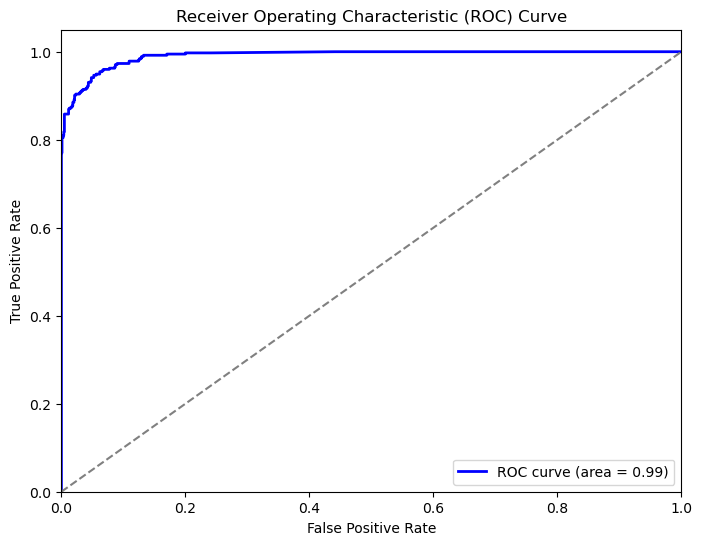

In [836]:
# Plotting the ROC curve
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, auc

final_model = best_models["LightGBM"]
final_model.fit(X_train_transformed, y_train)

y_test_proba = final_model.predict_proba(X_test_transformed)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_test_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()


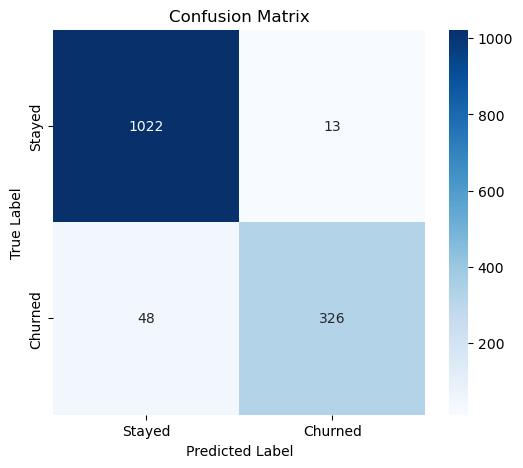

In [838]:
# plotting the Confusion Matrix
y_test_pred = final_model.predict(X_test_transformed)
conf_matrix = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Stayed', 'Churned'], yticklabels=['Stayed', 'Churned'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

/var/folders/mr/jhkmw9bs4_sgwx59sd88hcfw0000gn/T/ipykernel_38657/2895436264.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_20_lgbm_features["LightGBM Importance"], y=top_20_lgbm_features["Feature"], palette="coolwarm")


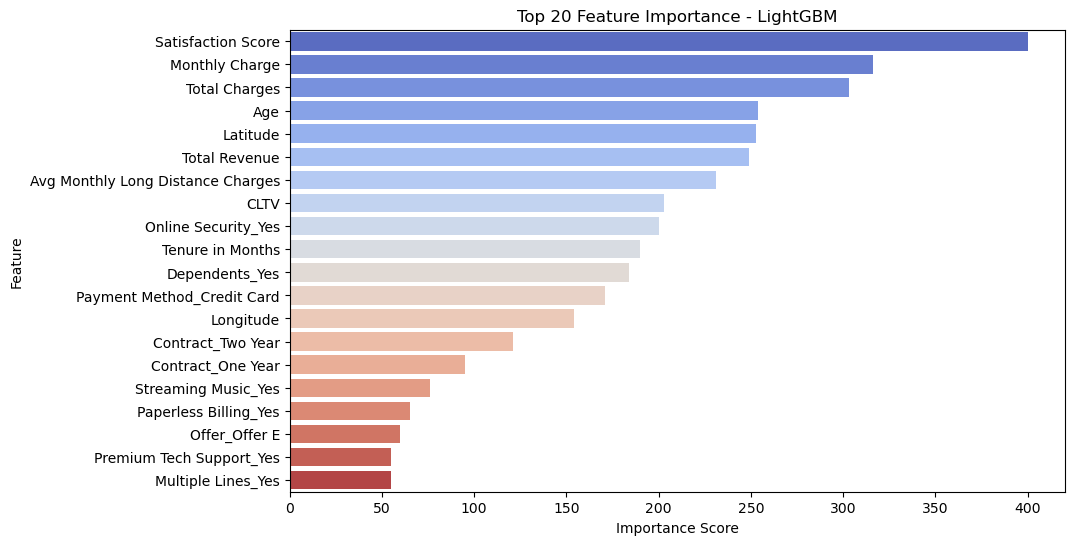

In [846]:
## Plotting feature importance from LightGBM
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

lgbm_importance = best_models["LightGBM"].feature_importances_

lgbm_importance_df = pd.DataFrame({"Feature": feature_names, "LightGBM Importance": lgbm_importance})

top_20_lgbm_features = lgbm_importance_df.sort_values(by="LightGBM Importance", ascending=False).head(20)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_20_lgbm_features["LightGBM Importance"], y=top_20_lgbm_features["Feature"], palette="coolwarm")

plt.title("Top 20 Feature Importance - LightGBM")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()
